In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_arch


---
# Aperçu de Yt

In [ ]:
data=pd.read_csv("velib_horaire.csv")
data["Departure_Time"]= pd.to_datetime(data["Departure_Time"])
data = data.sort_values("Departure_Time").set_index("Departure_Time")

print(data.head())


In [ ]:
Y=data["nombre_trajets"]

print("Moyenne :", Y.mean())
print("Variance :", Y.var())
print("Écart-type :", Y.std())

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(Y)
plt.title("Graphique A: Série temporelle Yt")
plt.xlabel("Heure de départ")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.show()

In [ ]:
print("p-value ADF :", adfuller(Y)[1])

---

# Recherche d'une tendance polynomiale

In [ ]:
# test d'une tendance polynomiale de degré 2
t = np.arange(len(Y))
X = sm.add_constant(np.column_stack([t, t**2]))
mod = sm.OLS(Y.values, X).fit()
print(mod.summary())

- la tendance quadratique n’est pas retenue car $t^2$ a une p-value de 0.177, donc non significative.
- la tendance linéaire est significative car $t$ a une p-value de 0.007, mais R-squared=0.022, donc elle explique seulement 2.2 % de la variabilité.

In [ ]:
# retrait de la tendance polynomiamle de degrès 1

X = sm.add_constant(t)

mod_lin = sm.OLS(Y.values, X).fit()

y_sans_tendance = Y - mod_lin.fittedvalues

---

# Recherche de saisonnalité

In [ ]:
profil_horaire = Y.groupby(Y.index.hour).mean()

plt.figure(figsize=(10,4))
plt.plot(profil_horaire.index, profil_horaire.values, marker="o")
plt.title("Moyenne du nombre de trajets par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de trajets")
plt.grid(True)
plt.show()

In [ ]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
profil_semaine = Y.groupby(Y.index.dayofweek).mean()

plt.figure(figsize=(8,4))
plt.plot(jours, profil_semaine.values, marker="o")
plt.title("Moyenne du nombre de trajets par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Moyenne")
plt.grid(True)
plt.show()

In [ ]:
stl = STL(Y, period=24, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14,10)
plt.show()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

- La composante de tendance est lisse et oscille beaucoup plus lentement que la série initiale, mais le niveau moyen du nombre de trajets change au cours du temps, donc la série n’est probablement pas stationnaire 

- la composante de saisonnalité présente des pics et des creuc réguliers. Elle n’a pas une amplitude constante sur toute la période. Donc il peut rester une structure supplémentaire.

- les résidus sont proche de 0 mais ils ne sont pas homogène, ils ne ressemblent pas à un bruit blanc 

In [ ]:
stl = STL(Y, period=168, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14,10)
plt.show()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

- la composante de tendance est encore plus régulière et globalement croissante 
- La composante saisonnière présente un motif périodique stable
- les résidus demeurent dispersés de manière inégale et contiennent encore plusieurs valeurs extrêmes

In [ ]:
# retrait de la saisonnalité

Y_diff = y_sans_tendance.diff(24).diff(168).dropna()

In [ ]:
print("p-value ADF :", adfuller(Y_diff)[1])

In [ ]:
Y_diff.plot(figsize=(12,4))
plt.show()

plot_acf(Y_diff, lags=24*10)
plt.show()

plot_pacf(Y_diff, lags=48)
plt.show()


### ACF
- forte décroissance au début : dépendance de court terme ;
- pic marqué vers 24 : possible composante saisonnière résiduelle de type MA/AR ;
- pic marqué vers 168 : même idée au niveau hebdomadaire.

### PACF
- pic très fort au lag 1 ;
- pics autour de 24 et 48 ;


cela suggère qu’un simple ARMA(p,q) avec petits ordres ne capturera pas bien la structure. Le modèle SARIMA est plus adapté

In [ ]:
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore")
Y_model = Y_diff.dropna()

p = range(0, 3)
q = range(0, 3)

resultats = []

for i, j in itertools.product(p, q):
    try:
        mod = sm.tsa.ARIMA(Y_model, order=(i, 0, j))
        res = mod.fit()

        if res.mle_retvals.get("converged", False):
            resultats.append({
                "p": i,
                "q": j,
                "modele": f"ARMA({i},{j})",
                "AIC": res.aic
            })

    except Exception:
        continue

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("AIC").reset_index(drop=True)

print("Tableau des modèles classés par AIC :")
display(df_resultats)

p_opt = int(df_resultats.loc[0, "p"])
q_opt = int(df_resultats.loc[0, "q"])
modele_opt = df_resultats.loc[0, "modele"]
aic_opt = df_resultats.loc[0, "AIC"]

print("Meilleur modèle retenu :", modele_opt)
print("AIC =", aic_opt)

res_final = sm.tsa.ARIMA(Y_model, order=(p_opt, 0, q_opt)).fit()
print(res_final.summary())


### Résultat du modèle ARMA(1,2)

Parmi les différents modèles testés, le modèle ARMA(1,2) est celui qui minimise le critère AIC. Il est donc retenu comme le meilleur modèle.

Les coefficients estimés sont significatifs, ce qui montre que la dépendance au passé et aux erreurs passées est bien prise en compte par le modèle. En revanche, la constante n’est pas significative.

L’analyse des résidus (test de Ljung-Box non significatif) montre qu’il n’y a plus d’autocorrélation, ce qui est un point positif. Même si les résidus ne sont pas parfaitement normaux et qu’il existe une légère hétéroscédasticité, le modèle reste globalement satisfaisant.

On peut donc utiliser ce modèle pour la suite de l’analyse..

 - Afin de valider le modèle, plusieurs tests sont réalisés sur les résidus. Le test de Ljung-Box permet de vérifier l’absence d’autocorrélation, le test de Shapiro-Wilk la normalité, et le test ARCH l’homoscédasticité. Les résultats sont résumés dans le tableau ci-dessous.

In [ ]:
residus = res_final.resid

# tests
ljung = acorr_ljungbox(residus, lags=[10], return_df=True)
shap_stat, shap_p = shapiro(residus)

#  tableau des résultats des tests
df_tests = pd.DataFrame({
    "Test": ["Ljung-Box", "Shapiro-Wilk"],
    "Statistique": [
        round(ljung["lb_stat"].values[0], 2),
        round(shap_stat, 2)
    ],
    "p-value": [
        round(ljung["lb_pvalue"].values[0], 2),
        round(shap_p, 2)
    ]
})

print(df_tests)

           Test  Statistique  p-value
0     Ljung-Box        22.07     0.01
1  Shapiro-Wilk         0.87     0.00


### Analyse des résidus

- Les graphiques de diagnostic permettent de vérifier visuellement la qualité du modèle. 
On observe que les résidus ne présentent pas de structure particulière et se comportent comme un bruit blanc.

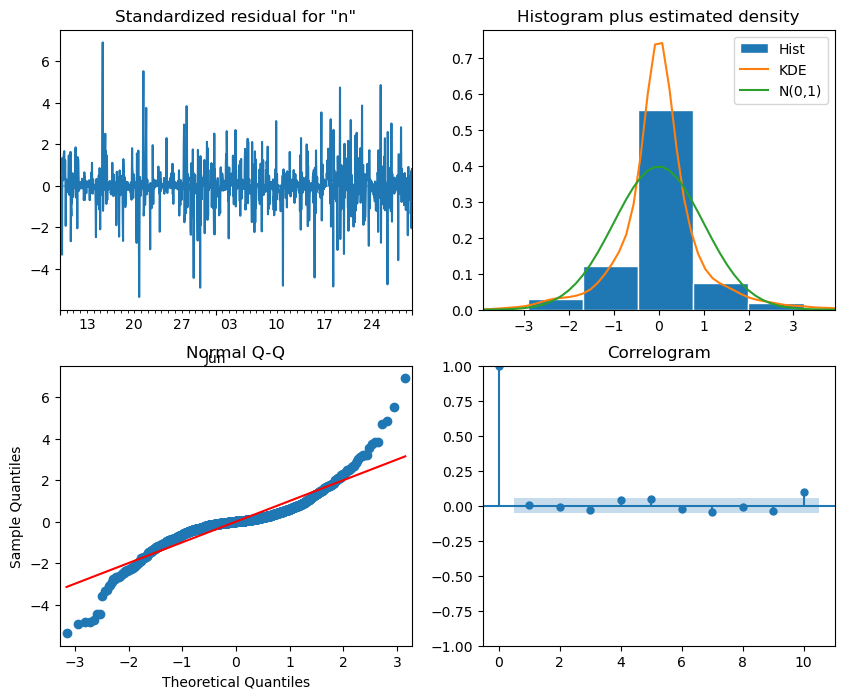

In [ ]:
fig = res_final.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()